These notebooks document the process of estimating subjective landscape beauty on a raster level for all of Europe. 

To acchieve this we replicate the work of [cite German paper]. 

Libraries, workflow and data sources

Several python and R libraries are used to run this document. 
Spatial data: terra

Data Visualization: leaflet 

Raster size, projection and alignment are chosen to fit the German reference data. 
1x1 km
EPSG: 3035

In [2]:
%load_ext rpy2.ipython

# About the German beauty model

In 2021 Roth et al. published a dataset, assigning a value of landscape beauty to each cell of a 1 by 1 kilometer grid in Germany. 
The basis for this map were user-rated landscape photos of Germany.  These photos were taken as part of a photo documentation project in 30 representative sampling areas, each approximately 150 km² in size, across Germany. The sampling areas represent the diversity of German landscapes, from coastal regions to the Alps, and from forested areas to rural regions and urban centers. An expert-selected set of over 800 landscape photos was evaluated through an online survey in collaboration with a citizen science panel of over 3,500 participants.

These images are analzed using GIS tools to extract the visable landscape features. These features include landcover, landuse and relief energy.
The features are chosen, such that a connection to a countrywide dataset there can be drawn.
This feature extraction also notes the distance of said features from the camera. For this purpose, the authors define 4 zones:

zone 1) 0 to 500m

zone 2) 500m to 2.000m

zone 3) 2.000m to 5.000m

zone 4) 5.000m to 10.000m

The link between user ratings and landscape features are then modeled using ordinary least square regressions.

The final map are then the prediciton of these models using the countrywide available datasets. 

Only the final output maps are open to the public unfortunatly. In order to acchieve our goal of extending these models to the rest of Europe, we first need to replicate the model as best as we can, based on the documentation, and then apply it to datasets that are available for the whole of the EU. 

In [31]:
%%R
install_if_missing <- function(pkg) {
  if (!require(pkg, character.only = TRUE)) {
    install.packages(pkg, dependencies = TRUE)
    library(pkg, character.only = TRUE)
  }
}

# Check and install the necessary packages
install_if_missing("raster")
install_if_missing("leaflet")
install_if_missing("ggplot2")
install_if_missing("dplyr")
install_if_missing("tidyr")
install_if_missing("sf")
install_if_missing("patchwork")

Loading required package: sf
Linking to GEOS 3.10.2, GDAL 3.4.1, PROJ 8.2.1; sf_use_s2() is TRUE


# Exploring the model

The authors apply well established feature selection methods to reduce the initial 80+ covariates down to 17 for beauty. 

(* = significant (α = 0.05); ** = highly significant (α = 0.001)).

| No. | Regressor                                              | Area of Influence                 | Unstandardized Coefficients         | Standardized Coefficients (Beta)    |
|-----|--------------------------------------------------------|------------------------------------|--------------------------------------|-------------------------------------|
| 1   | Constant                                               | /                                  | 7.109                                | /                                   |
| 2   | Terrain Height Difference 1                            | 0 to 2,000 m (Zones 1 and 2)       | + 0.002**                            | + 0.171**                           |
| 3   | Terrain Height Difference 2                            | 2,000 to 10,000 m (Zones 3 and 4)  | + 0.001**                            | + 0.185**                           |
| 4   | Lakes, Seas, Watercourses                              | 0 to 500 m (Zone 1)                | + 0.008**                            | + 0.152**                           |
| 5   | Orchards                                               | Entire area of influence           | + 0.031**                            | + 0.096**                           |
| 6   | Forest                                                 | Entire area of influence           | + 0.005*                             | + 0.088*                            |
| 7   | Natural Grassland                                      | 500 to 2,000 m (Zone 2)            | + 0.025**                            | + 0.083**                           |
| 8   | Heaths, Moorlands                                      | 0 to 500 m (Zone 1)                | + 0.017*                             | + 0.068*                            |
| 9   | Degree of Hemoroby                                     | 0 to 500 m (Zone 1)                | - 0.317**                            | - 0.200**                           |
| 10  | Road Density                                           | 0 to 2,000 m (Zones 1 and 2)       | - 0.0001**                           | - 0.189**                           |
| 11  | Arable Land                                            | Entire area of influence           | - 0.010**                            | - 0.187**                           |
| 12  | Industrial, Commercial, Traffic, Mining, Landfills, Construction Areas 1 | 0 to 500 m (Zone 1)               | - 0.019**                            | - 0.187**                           |
| 13  | Industrial, Commercial, Traffic, Mining, Landfills, Construction Areas 2 | 500 to 2,000 m (Zone 2)           | - 0.018**                            | - 0.106**                           |
| 14  | Industrial, Commercial, Traffic, Mining, Landfills, Construction Areas 3 | 2,000 to 5,000 m (Zone 3)         | - 0.011*                             | - 0.065*                            |
| 15  | Power Line Density                                     | 0 to 500 m (Zone 1)                | - 0.0001**                           | - 0.101**                           |
| 16  | Sports and Recreation Facilities                       | 0 to 500 m (Zone 1)                | - 0.019**                            | - 0.077**                           |
| 17  | Sparse Vegetation                                      | 500 to 2,000 m (Zone 2)            | - 0.205*                             | - 0.075*                            |
| 18  | Wind Turbine Density                                   | Entire area of influence           | - 0.588*                             | - 0.071*                            |


This table will form the basis for our model. Since the only data at our disposal are the final output maps, we only need to consider these covariates for our model.
Where possible we use the same datasets as the authors and apply the same transformations as them.

# Datasets

## Elevation

The authors use the "Digitales Geländemodell (DGM)" which is based on Airborn Laserscanning. 
We use the EU wide version digital elevation model over Europe (EU-DEM) published by eurostat.  [cite]

## Landcover and Landuse

The basis for the landcover related variables are the Corine Landcover Classes. 
Specifically in the model are:

| Name                                   | Corine Landcover Codes              |
|----------------------------------------|-------------------------------------|
| Orchards                               | 222                                 |
| Forest                                 | 311, 312, 313                      |
| Natural Grassland                      | 321                                 |
| Moors and Heathland                    | 322                                 |
| Arable Land                            | 211                                 |
| Industrial, Commercial, Traffic, Mining, Landfills, Construction | 121, 122, 123, 124, 131, 132, 133 |
| Sports and Recreation Facilities       | 142                                 |
| Sparse Vegetation                      | 333                                 |
| Lakes, Seas, Watercourses              | 512, 521, 522, 523                 |

     

We use the 2018 Corine Landcover classes at 100x100m resolution. 
Following the reference paper, we calculate the share of selected classes within each cell in our target raster (1x1km)

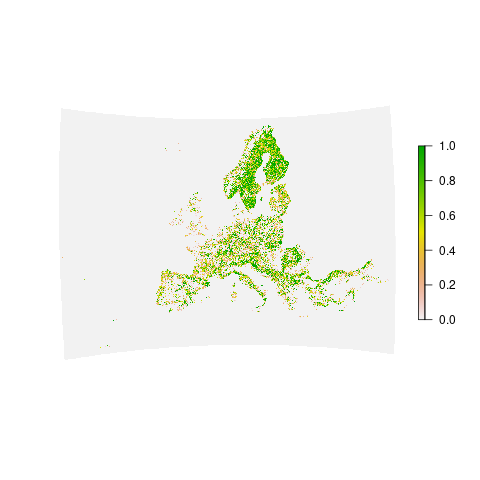

In [16]:
%%R

library(leaflet)
library(raster)

r <- raster("../data/cleaned/clc/layer_coverage_EU/code_wald.tif")

plot(r, axes = FALSE, box = FALSE)

# Open Street Maps

For road, wind turbine and powerpole density we use Open street maps, as do the authors of the reference paper. 

We downloaded an EU wide dataset published by geofabrik [cite] and extract the relevant features as vectors, which are then converted to density per cell. 
The points data (windturbines and powerpoles) are encoded as "number of elements in the cell", whereas the line data for roads is encoded as "total length within the cell"

# Harmonizing the input data

In addition: Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 


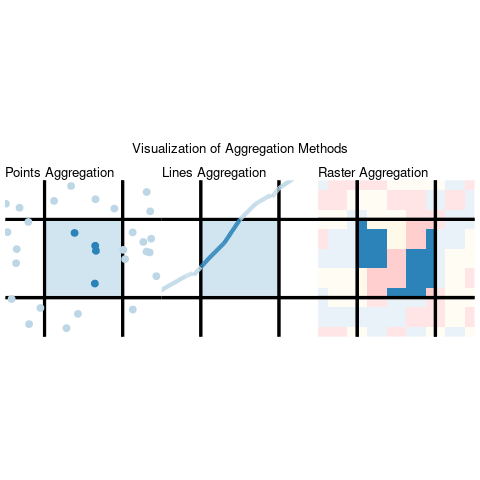

In [35]:
%%R 

create_raster_cell <- function() {
  expand.grid(x = -1:1, y = -1:1) %>%
    mutate(is_center = ifelse(x == 0 & y == 0, "center", "periphery"))
}

# Example 1: Point Data
plot_points <- function() {
  raster_cell <- create_raster_cell()
  points_data <- data.frame(
    x = runif(30, -1, 1),
    y = runif(30, -1, 1)
  ) %>%
    mutate(position = ifelse(abs(x) <= 0.5 & abs(y) <= 0.5, "inside", "outside"))
  
  ggplot() +
    geom_tile(data = raster_cell, aes(x, y, fill = is_center), color = "black", linewidth = 1.5) +
    geom_point(data = points_data, aes(x, y, color = position), size = 3) +
    scale_fill_manual(values = c("center" = "#d1e5f0", "periphery" = "white")) +
    scale_color_manual(values = c("inside" = "#2b83ba", "outside" = "#bdd7e7")) +
    coord_fixed(xlim = c(-1, 1), ylim = c(-1, 1), expand = FALSE) +
    labs(title = "Points Aggregation") + 
    theme_void() + theme(legend.position = "none") 
}

plot_lines <- function() {
  raster_cell <- create_raster_cell()
  
  # Create a jagged line with additional points around cell borders
  line_data <- data.frame(
    x = c(-1.2, -0.9, -0.6, -0.51,  -0.49, -0.3, -0.1, 0.1, 0.101, 0.3, 0.49, 0.51, 0.6, 0.9, 1.2) - 0.1,
    y = c(-1.0, -0.7, -0.53, -0.49, -0.51, -0.3, -0.1, 0.2, 0.201, 0.4, 0.51, 0.49, 0.6, 0.8, 1.0) + 0.3
  )
  
  interpolated_points <- data.frame(x = numeric(), y = numeric())
  
  # Loop through pairs of points
  for (i in 1:(nrow(line_data) - 1)) {
    # Generate 10 points between the current and next point
    x_points <- seq(line_data$x[i], line_data$x[i + 1], length.out = 22)  # Include start and end
    y_points <- seq(line_data$y[i], line_data$y[i + 1], length.out = 22)  # Include start and end
    
    # Add to the new data frame, excluding the last point to avoid duplicates
    interpolated_points <- rbind(interpolated_points, data.frame(x = x_points[-length(x_points)], y = y_points[-length(y_points)]))
  }
  
  # Add the final point
  line_data <- rbind(interpolated_points, line_data[nrow(line_data), ])
  line_data <- line_data  %>%
    mutate(position = ifelse(abs(x) <= 0.5 & abs(y) <= 0.5, "inside", "outside"))
  
  ggplot() +
    geom_tile(data = raster_cell, aes(x, y, fill = is_center), color = "black", linewidth = 1.5) +
    geom_path(data = line_data, aes(x, y, color = position, group = 1), linewidth = 2) +
    scale_fill_manual(values = c("center" = "#d1e5f0", "periphery" = "white")) +
    scale_color_manual(values = c("inside" = "#2b83ba", "outside" = "#bdd7e7")) +
    theme_void()  + theme(legend.position = "none") +
    labs(title = "Lines Aggregation") + 
    coord_fixed(xlim = c(-1, 1), ylim = c(-1, 1), expand = FALSE)
}



plot_smaller_raster <- function() {
  raster_cell <- create_raster_cell()
  # Define the big raster cell as an sf polygon
  big_raster <- st_sf(
    geometry = st_sfc(
      st_polygon(list(matrix(c(-0.5, -0.5,
                               0.5, -0.5,
                               0.5, 0.5,
                               -0.5, 0.5,
                               -0.5, -0.5),
                             ncol = 2, byrow = TRUE)))
    )
  ) %>%
    mutate(type = "center")
  
  # Define the smaller raster cells as sf polygons
  grid_points <- expand.grid(
    x = seq(-1, 1, by = 0.25),
    y = seq(-1, 1, by = 0.25)
  )
  
  small_raster <- grid_points %>%
    rowwise() %>%
    mutate(
      geometry = list(st_polygon(list(
        matrix(
          c(
            x - 0.125, y - 0.125,
            x + 0.125, y - 0.125,
            x + 0.125, y + 0.125,
            x - 0.125, y + 0.125,
            x - 0.125, y - 0.125
          ),
          ncol = 2, byrow = TRUE
        )
      ))),
      class = sample(1:3, 1)
    ) %>%
    st_as_sf()
  
  small_raster$color <- case_when(small_raster$class == 1 ~ "#2b83ba", 
                                  small_raster$class == 2 ~ "red",
                                  small_raster$class == 3 ~ "#FFE397")
  
  
  # Chop the smaller raster with the big raster
  clipped_raster <- st_intersection(small_raster, big_raster)
  
  # Add inside/outside status and adjust saturation for "1" class
  clipped_raster <- clipped_raster %>%
    mutate(
      position = ifelse(st_within(st_centroid(geometry), big_raster, sparse = FALSE)[, 1], "inside", "outside"),
      color = case_when(
        class == 1 & position == "inside" ~ "#2b83ba", 
        class == 1 & position == "outside" ~ "#2b83ba",
        class == 2 ~ "red",                        
        class == 3 ~ "#FFE397"
      )
    )
  alpha_value = 0.1
  clipped_raster$alpha <- ifelse(clipped_raster$position == 'inside' & clipped_raster$class == 1, 1, alpha_value)

  # Plot
  ggplot() +
    geom_sf(data = small_raster, aes(fill = color), color = NA, alpha = alpha_value) + 
    geom_sf(data = clipped_raster, aes(fill = color, alpha = alpha), color =NA) +  
    geom_tile(data = raster_cell, aes(x, y), color = "black", fill = NA, linewidth = 1.5) +
    scale_fill_identity() + theme(legend.position = "none") +
    scale_alpha_identity() + 
    coord_sf(xlim = c(-1, 1), ylim = c(-1, 1), expand = FALSE)+ 
    labs(title = "Raster Aggregation") + 
    theme_void()
}

(plot_points() | plot_lines() | plot_smaller_raster()) +
  plot_annotation(title = "Visualization of Aggregation Methods",
                  theme = theme(plot.title = element_text(hjust = 0.5)))

# Neighborhoods

In order to treat landscape features that are further in the distance, differently than ones that are up close, we add variables that give the average value of each feature, for the neighboring cells. 

The neighborhood gets split into 4 zones, where 1 is the cell itself and subsequent zones are further out as described in the discussion of the reference model. 

Below you can see the neighborhood zones for a raster with resolution 100m. 

In [46]:
from rural_beauty import blur_circular_disc

4*blur_circular_disc.create_circular_disc(9.9, 10) - blur_circular_disc.create_circular_disc(4.9, 10) - blur_circular_disc.create_circular_disc(1.9, 10) - blur_circular_disc.create_circular_disc(0.9, 10)

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0],
       [0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0],
       [0, 0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 0],
       [0, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0],
       [0, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 3, 3, 3, 2, 1, 2, 3, 3, 3, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 3, 3, 3, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 0],
       [0, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4,